# Visualizing the Gradient Descent Method

- Gabriel Wendell Celestino Rocha
---

## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def opt_plot_ax(ax):
    # ax.style.use('dark_background')
    ax.grid(True, linestyle = ':', color = '0.50')
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 15
    plt.minorticks_on()
    plt.tick_params(axis = 'both', which = 'minor', direction = "in",
                        top = True, right = True, length = 5, width = 1, labelsize = 15)
    plt.tick_params(axis = 'both', which = 'major', direction = "in",
                        top = True, right = True, length = 8, width = 1, labelsize = 15)

---

## The Method

In the gradient descent method of optimization, a *hypothesis function*, $h_{\theta}\left(x\right)$, is fitted to a data set, $\left(x^{(i)},y^{(i)}\right)$, with $i=1,2,\ldots,m$, by minimizing an associated *cost function*, $J\left(\boldsymbol{\theta}\right)$ in terms of the parameters $\boldsymbol{\theta}=\theta_{0},\theta_{1},\ldots$. The cost function describes how closely the hypothesis fits the data for a given choice of $\boldsymbol{\theta}$.

For example, one might wish to fit a given data set to a straight line:

$$\tag{1}
h_{\theta}\left(x\right)=\theta_{0}+\theta_{1}x\text{ }.
$$

An appropriate cost function might be the sum of the squared difference between the data and the hypothesis:

$$\tag{2}
J\left(\boldsymbol{\theta}\right)=\frac{1}{2m}\sum_{i=1}^{m}\left[h_{\theta}\left(x^{(i)}\right)-y^{(i)}\right]^{2}\text{ }.
$$

The gradient descent method starts with a set of initial parameter values of $\boldsymbol{\theta}$ (say, $\theta_{0}=0$, $\theta_{1}=0$) and then follows an iterative procedure, changing the values of $\theta_{j}$ so that $J\left(\boldsymbol{\theta}\right)$ decreases:

$$\tag{3}
\theta_{j}\rightarrow\theta_{j}-\alpha\frac{\partial}{\partial \theta j}\left[J\left(\boldsymbol{\theta}\right)\right]\text{ }.
$$

To simplify things, consider fitting a data set to a straight line through the origin: $h_{\theta}\left(x\right)=\theta_{1}x$. In this one-dimensional problem, we can plot a simple graph for $J\left(\theta_{1}\right)$ and follow the iterative procedure which trys to converge on its minimum.

## The Code

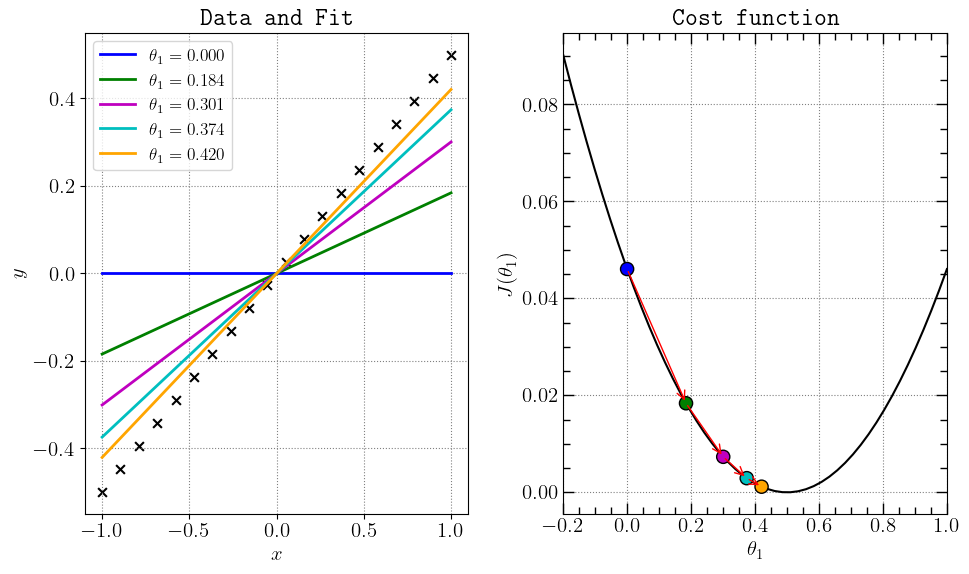

In [3]:
# The data to fit
m = 20
theta1_true = 0.5
x = np.linspace(-1,1,m)
y = theta1_true * x

# The plot: LHS is the data, RHS will be the cost function.
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 6))
ax[0].scatter(x, y, marker = 'x', s = 40, color = 'k')

def cost_func(theta1):
    """The cost function, J(theta1) describing the goodness of fit."""
    theta1 = np.atleast_2d(np.asarray(theta1))
    return np.average((y - hypothesis(x, theta1))**2, axis = 1)/2

def hypothesis(x, theta1):
    """Our "hypothesis function", a straight line through the origin."""
    return theta1*x

# First construct a grid of theta1 parameter pairs and their corresponding
# cost function values.
theta1_grid = np.linspace(-0.2, 1, 50)
J_grid = cost_func(theta1_grid[:,np.newaxis])

# The cost function as a function of its single parameter, theta1.
ax[1].plot(theta1_grid, J_grid, 'k')

# Take N steps with learning rate alpha down the steepest gradient,
# starting at theta1 = 0.
N = 5
alpha = 1
theta1 = [0]
J = [cost_func(theta1[0])[0]]
for j in range(N - 1):
    last_theta1 = theta1[-1]
    this_theta1 = last_theta1 - alpha / m * np.sum(
                                    (hypothesis(x, last_theta1) - y) * x)
    theta1.append(this_theta1)
    J.append(cost_func(this_theta1)[0])

# Annotate the cost function plot with coloured points indicating the
# parameters chosen and red arrows indicating the steps down the gradient.
# Also plot the fit function on the LHS data plot in a matching colour.
colors = ['b', 'g', 'm', 'c', 'orange']
ax[0].plot(x, hypothesis(x, theta1[0]), color = colors[0], lw = 2,
           label = r'$\theta_1 = {:.3f}$'.format(theta1[0]))
for j in range(1, N):
    ax[1].annotate('', xy = (theta1[j], J[j]), xytext = (theta1[j-1], J[j-1]),
                   arrowprops = {'arrowstyle': '->', 'color': 'r', 'lw': 1},
                   va = 'center', ha = 'center')
    ax[0].plot(x, hypothesis(x, theta1[j]), color = colors[j], lw = 2,
               label = r'$\theta_1 = {:.3f}$'.format(theta1[j]))

# Labels, titles and a legend.
J_arr = np.array([float(j) for j in J])
theta1_arr = np.array([float(t) for t in theta1])
ax[1].scatter(theta1_arr, J_arr, c = colors[:N], s = 90, edgecolor = 'k', linewidths = 1, zorder = 2)
ax[1].set_xlim(-0.2,1)
ax[1].set_xlabel(r'$\theta_1$')
ax[1].set_ylabel(r'$J(\theta_1)$')
ax[1].set_title('Cost function')
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')
ax[0].set_title('Data and Fit')
ax[0].legend(loc = 'best', fontsize = 'small')

plt.tight_layout()
opt_plot_ax(ax[0])
opt_plot_ax(ax[1])
plt.show()

Fitting a general straight line to a data set requires two parameters, and so $J\left(\theta_{0},\theta_{1}\right)$ can be visualized as a contour plot. The same iterative procedure over these two parameters can also be followed as points on this plot.

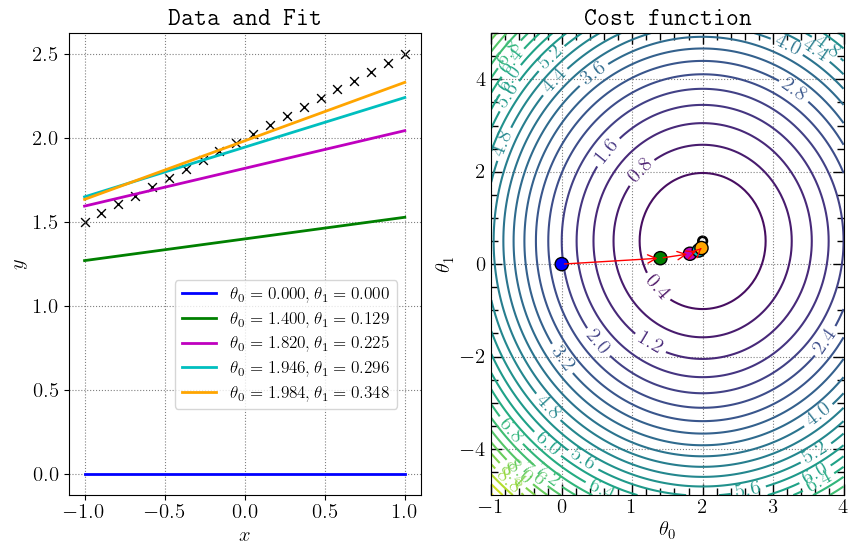

In [4]:
# The data to fit
m = 20
theta0_true = 2
theta1_true = 0.5
x = np.linspace(-1,1,m)
y = theta0_true + theta1_true * x

# The plot: LHS is the data, RHS will be the cost function.
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 6))
ax[0].scatter(x, y, marker = 'x', s = 40, color = 'white', facecolor = 'k', linewidth = 1)

def cost_func(theta0, theta1):
    """The cost function, J(theta0, theta1) describing the goodness of fit."""
    theta0 = np.atleast_3d(np.asarray(theta0))
    theta1 = np.atleast_3d(np.asarray(theta1))
    return np.average((y - hypothesis(x, theta0, theta1))**2, axis = 2)/2

def hypothesis(x, theta0, theta1):
    """Our "hypothesis function", a straight line."""
    return theta0 + theta1*x

# First construct a grid of (theta0, theta1) parameter pairs and their
# corresponding cost function values.
theta0_grid = np.linspace(-1, 4, 101)
theta1_grid = np.linspace(-5, 5, 101)
J_grid = cost_func(theta0_grid[np.newaxis,:,np.newaxis],
                   theta1_grid[:,np.newaxis,np.newaxis])

# A labeled contour plot for the RHS cost function
X, Y = np.meshgrid(theta0_grid, theta1_grid)
contours = ax[1].contour(X, Y, J_grid, 30)
ax[1].clabel(contours)
# The target parameter values indicated on the cost function contour plot
ax[1].scatter([theta0_true]*2,[theta1_true]*2, s = [50,10], color = ['k','w'])

# Take N steps with learning rate alpha down the steepest gradient,
# starting at (theta0, theta1) = (0, 0).
N = 5
alpha = 0.7
theta = [np.array((0,0))]
J = [cost_func(*theta[0])[0]]
for j in range(N-1):
    last_theta = theta[-1]
    this_theta = np.empty((2,))
    this_theta[0] = last_theta[0] - alpha / m * np.sum(
                                    (hypothesis(x, *last_theta) - y))
    this_theta[1] = last_theta[1] - alpha / m * np.sum(
                                    (hypothesis(x, *last_theta) - y) * x)
    theta.append(this_theta)
    J.append(cost_func(*this_theta))


# Annotate the cost function plot with coloured points indicating the
# parameters chosen and red arrows indicating the steps down the gradient.
# Also plot the fit function on the LHS data plot in a matching colour.
colors = ['b', 'g', 'm', 'c', 'orange']
ax[0].plot(x, hypothesis(x, *theta[0]), color = colors[0], lw = 2,
           label = r'$\theta_0 = {:.3f}, \theta_1 = {:.3f}$'.format(*theta[0]))
for j in range(1,N):
    ax[1].annotate('', xy = theta[j], xytext = theta[j-1],
                   arrowprops = {'arrowstyle': '->', 'color': 'r', 'lw': 1},
                   va = 'center', ha = 'center')
    ax[0].plot(x, hypothesis(x, *theta[j]), color = colors[j], lw = 2,
           label = r'$\theta_0 = {:.3f}, \theta_1 = {:.3f}$'.format(*theta[j]))
ax[1].scatter(*zip(*theta), c = colors,  s = 90, edgecolor = 'k', lw = 1, zorder = 2)

# Labels, titles and a legend.
ax[1].set_xlabel(r'$\theta_0$')
ax[1].set_ylabel(r'$\theta_1$')
ax[1].set_title('Cost function')
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')
ax[0].set_title('Data and Fit')
axbox = ax[0].get_position()
# Position the legend by hand so that it doesn't cover up any of the lines.
ax[0].legend(loc = (axbox.x0 + 0.5*axbox.width, axbox.y0 + 0.1*axbox.height),
             fontsize = 'small')

opt_plot_ax(ax[0])
opt_plot_ax(ax[1])
plt.show()

---